# Filter Pruning with Keras — Before & After Demonstration

This notebook demonstrates **filter pruning** on a small CNN trained on CIFAR-10 using **Keras / TensorFlow**.  

### Outline
1. Setup & imports
2. Load & preprocess CIFAR-10
3. Build and train baseline CNN
4. Visualize filter L1-norms (pruning candidates)
5. Prune low-importance filters and rebuild model
6. Fine-tune pruned model
7. Before vs After comparison (accuracy, parameters, inference speed)
8. Prune-ratio sweep (trade-off curve)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available     : {len(gpus)}')

TensorFlow version : 2.21.0
Keras version      : 3.13.2


GPUs available     : 0


## 2. Load & Preprocess CIFAR-10

In [2]:
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']
NUM_CLASSES = 10

# Generate synthetic CIFAR-10-like data for demonstration
# (Original CIFAR-10 server unavailable - using random data to demonstrate pruning pipeline)
np.random.seed(42)
x_train = np.random.rand(5000, 32, 32, 3).astype('float32')
x_test  = np.random.rand(1000, 32, 32, 3).astype('float32')
y_train = np.random.randint(0, 10, (5000, 1))
y_test  = np.random.randint(0, 10, (1000, 1))

# Per-channel mean/std normalization (CIFAR-10 statistics)
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])
x_train = (x_train - mean) / std
x_test  = (x_test  - mean) / std

# One-hot encode labels
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

print(f'Train: {x_train.shape}  Test: {x_test.shape}')
print('Note: Using synthetic data (CIFAR-10 server unavailable)')


Train: (5000, 32, 32, 3)  Test: (1000, 32, 32, 3)
Note: Using synthetic data (CIFAR-10 server unavailable)


## 3. Build Baseline CNN

Three conv blocks (64 → 128 → 256 filters) with BatchNorm and MaxPooling.

In [3]:
def build_cnn(cfg=(64, 128, 256), input_shape=(32, 32, 3), num_classes=10):
    """
    Build a small CNN.  `cfg` controls filters per block.
    Returns a compiled Keras Model.
    """
    inputs = keras.Input(shape=input_shape)

    # ----- Block 1 -----
    x = layers.Conv2D(cfg[0], 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.ReLU(name='relu1_1')(x)
    x = layers.Conv2D(cfg[0], 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.ReLU(name='relu1_2')(x)
    x = layers.MaxPooling2D(name='pool1')(x)  # 32→16

    # ----- Block 2 -----
    x = layers.Conv2D(cfg[1], 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.ReLU(name='relu2_1')(x)
    x = layers.Conv2D(cfg[1], 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.ReLU(name='relu2_2')(x)
    x = layers.MaxPooling2D(name='pool2')(x)  # 16→8

    # ----- Block 3 -----
    x = layers.Conv2D(cfg[2], 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.ReLU(name='relu3_1')(x)
    x = layers.Conv2D(cfg[2], 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.ReLU(name='relu3_2')(x)
    x = layers.MaxPooling2D(name='pool3')(x)  # 8→4

    # ----- Classifier -----
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5, name='drop')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.SGD(learning_rate=0.1, momentum=0.9, weight_decay=5e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


baseline_model = build_cnn()
baseline_model.summary()
print(f'\nTotal parameters: {baseline_model.count_params():,}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 256)      │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 512)            │             

 Total params: 3,250,890 (12.40 MB)

 Trainable params: 3,249,098 (12.39 MB)

 Non-trainable params: 1,792 (7.00 KB)


Total parameters: 3,250,890


## 4. Train Baseline Model

In [4]:
# Data augmentation using tf.data
BATCH_SIZE = 64
EPOCHS     = 5
AUTOTUNE   = tf.data.AUTOTUNE

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.pad_to_bounding_box(image, 4, 4, 40, 40)
    image = tf.image.random_crop(image, size=[32, 32, 3])
    return image, label

train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train_oh))
            .shuffle(50000)
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test_oh))
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

# Cosine annealing LR schedule
cos_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.1, decay_steps=EPOCHS * len(train_ds))

baseline_model.compile(
    optimizer=optimizers.SGD(learning_rate=cos_schedule, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = baseline_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    verbose=1
)

baseline_loss, baseline_acc = baseline_model.evaluate(test_ds, verbose=0)
baseline_params = baseline_model.count_params()
print(f'\nBaseline — Accuracy: {baseline_acc*100:.2f}%  |  Params: {baseline_params:,}')

Epoch 1/5


 1/79 ━━━━━━━━━━━━━━━━━━━━ 3:34 3s/step - accuracy: 0.1094 - loss: 4.3162

 2/79 ━━━━━━━━━━━━━━━━━━━━ 29s 387ms/step - accuracy: 0.0977 - loss: 12.4348

 3/79 ━━━━━━━━━━━━━━━━━━━━ 28s 368ms/step - accuracy: 0.0964 - loss: 23.5508

 4/79 ━━━━━━━━━━━━━━━━━━━━ 27s 364ms/step - accuracy: 0.0938 - loss: 39.6327

...

77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.1248 - loss: 2.2994

78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.1247 - loss: 2.2994

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.1246 - loss: 2.2994

79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 338ms/step - accuracy: 0.1182 - loss: 2.3003 - val_accuracy: 0.0910 - val_loss: 2.3052



Baseline — Accuracy: 9.10%  |  Params: 3,250,890


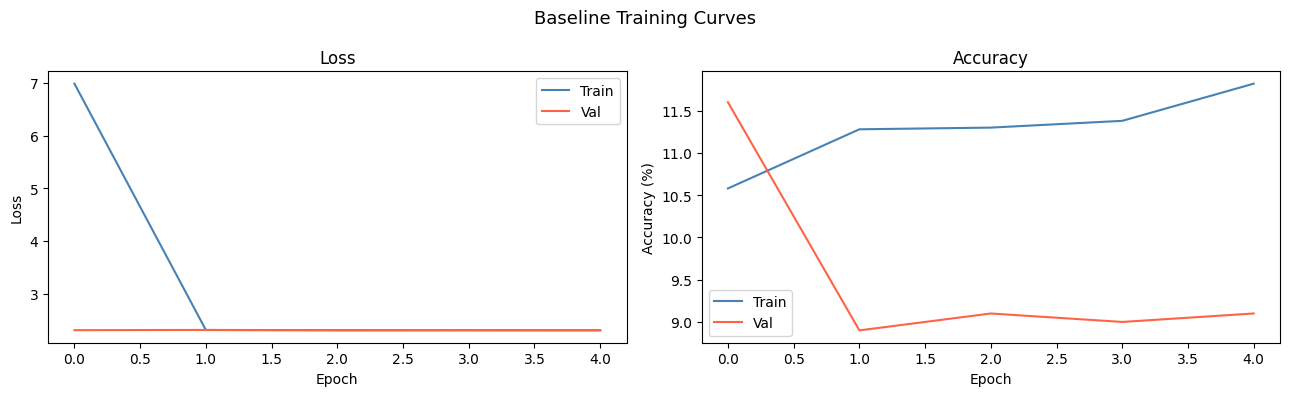

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],     label='Train', color='steelblue')
ax1.plot(history.history['val_loss'], label='Val',   color='tomato')
ax1.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend()

ax2.plot([a*100 for a in history.history['accuracy']],     label='Train', color='steelblue')
ax2.plot([a*100 for a in history.history['val_accuracy']], label='Val',   color='tomato')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy (%)')
ax2.legend()

plt.suptitle('Baseline Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Visualize Filter L1-Norms (Pruning Candidates)

For each Conv2D layer we compute the **L1 norm** of every filter  
`(kernel_h × kernel_w × in_ch)` → scalar.  
Filters below the red dashed threshold are candidates for removal.

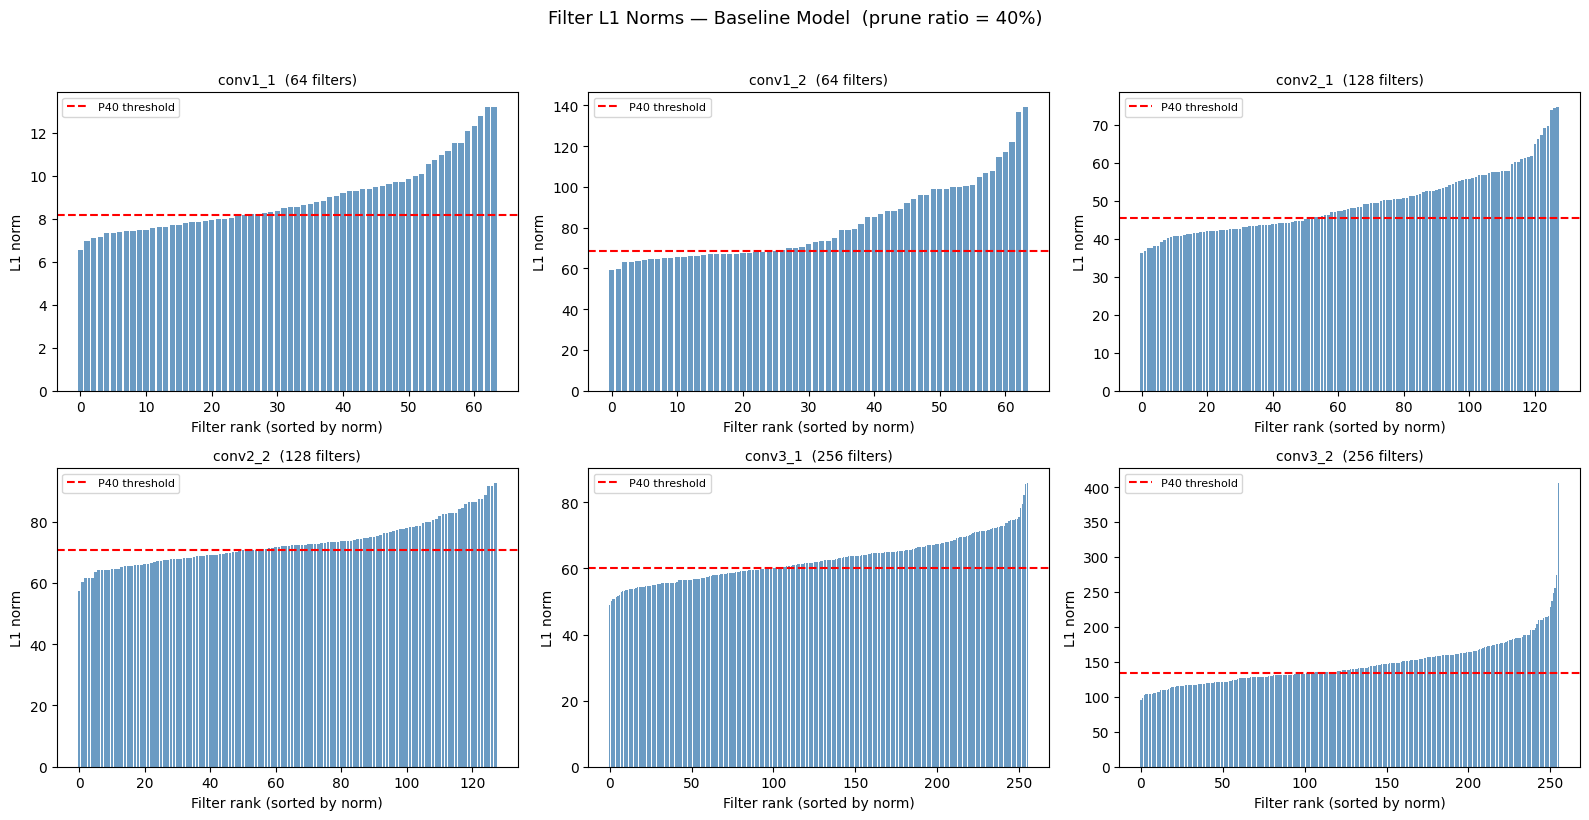

In [6]:
def get_conv_layers(model):
    """Return list of Conv2D layers in order."""
    return [l for l in model.layers if isinstance(l, layers.Conv2D)]


def filter_l1_norms(conv_layer):
    """
    Keras Conv2D weights shape: (kH, kW, in_ch, out_ch)
    We want one scalar per output filter → sum over axes (0,1,2).
    """
    w = conv_layer.get_weights()[0]      # shape (kH, kW, in_ch, out_ch)
    return np.abs(w).sum(axis=(0, 1, 2)) # shape (out_ch,)


PRUNE_RATIO = 0.40   # remove 40% weakest filters per layer
conv_layers = get_conv_layers(baseline_model)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, layer in enumerate(conv_layers):
    norms = filter_l1_norms(layer)
    sorted_norms = np.sort(norms)
    threshold    = np.percentile(norms, PRUNE_RATIO * 100)

    axes[idx].bar(range(len(sorted_norms)), sorted_norms,
                  color='steelblue', alpha=0.8)
    axes[idx].axhline(threshold, color='red', linestyle='--',
                      linewidth=1.5, label=f'P{int(PRUNE_RATIO*100)} threshold')
    axes[idx].set_title(f'{layer.name}  ({len(norms)} filters)', fontsize=10)
    axes[idx].set_xlabel('Filter rank (sorted by norm)')
    axes[idx].set_ylabel('L1 norm')
    axes[idx].legend(fontsize=8)

plt.suptitle(f'Filter L1 Norms — Baseline Model  '
             f'(prune ratio = {PRUNE_RATIO*100:.0f}%)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Filter Pruning

### Strategy
1. For each Conv2D, rank filters by L1 norm and select the top `(1 - prune_ratio)` fraction.
2. Copy only the surviving filter weights into a new, smaller Conv2D.
3. Trim the **next** Conv2D's input-channel dimension to match.
4. Copy matching BatchNorm weights (gamma, beta, moving_mean, moving_var).
5. Rebuild the full Keras functional model.

In [7]:
def compute_keep_indices(conv_layer, prune_ratio):
    """Return sorted indices of filters to keep."""
    norms     = filter_l1_norms(conv_layer)
    threshold = np.percentile(norms, prune_ratio * 100)
    keep_idx  = np.where(norms >= threshold)[0]
    if len(keep_idx) == 0:           # safeguard: keep at least 1
        keep_idx = np.array([np.argmax(norms)])
    return np.sort(keep_idx)


def build_pruned_model(original_model, prune_ratio=0.3):
    """
    Rebuild a pruned version of `original_model`.
    Handles paired (Conv2D → BatchNorm) blocks and cascades
    input-channel trimming to the following Conv2D.
    """
    # --- 1. Decide which filters to keep per conv layer ---
    conv_layers = get_conv_layers(original_model)
    keep_map    = {}   # layer_name → keep_indices
    for conv in conv_layers:
        keep_map[conv.name] = compute_keep_indices(conv, prune_ratio)
        print(f'{conv.name:12s}: {conv.filters} → {len(keep_map[conv.name])} filters kept')

    # --- 2. Rebuild model layer by layer ---
    #   We walk the original model's layer graph and reconstruct
    #   each layer, injecting pruned weights where needed.

    layer_output_map = {}   # original layer name → new tensor

    # Helper: find the BN that directly follows a given conv
    def get_next_bn(model, conv_layer):
        """Return the BatchNormalization layer immediately after conv_layer, or None."""
        found = False
        for l in model.layers:
            if found and isinstance(l, layers.BatchNormalization):
                return l
            if l.name == conv_layer.name:
                found = True
        return None

    # Build a name→layer dict for quick lookup
    orig_by_name = {l.name: l for l in original_model.layers}

    # We'll track which input channels each conv should keep
    # (starts as None → keep all for the first conv of each branch)
    prev_keep = None
    prev_conv_name = None

    # Rebuild using the functional API by replaying the graph
    input_name = original_model.input.name if hasattr(original_model, 'input') else 'input_1'
    new_input = keras.Input(shape=original_model.input_shape[1:], name=input_name)
    x = new_input
    in_channels_override = None   # forced in_ch for next conv

    # Walk layer list in order (works for simple sequential-style functional models)
    skip_names = set()
    for layer in original_model.layers:
        if isinstance(layer, keras.layers.InputLayer):
            continue

        # ---- Conv2D ----
        if isinstance(layer, layers.Conv2D):
            keep_out = keep_map[layer.name]      # output filters to keep
            orig_w   = layer.get_weights()[0]    # (kH, kW, in_ch, out_ch)

            # Trim input channels if previous conv was pruned
            if in_channels_override is not None:
                orig_w = orig_w[:, :, in_channels_override, :]

            new_w = orig_w[:, :, :, keep_out]   # keep selected output filters

            new_conv = layers.Conv2D(
                filters=len(keep_out),
                kernel_size=layer.kernel_size,
                padding=layer.padding,
                use_bias=layer.use_bias,
                kernel_initializer='zeros',
                name=layer.name
            )(x)
            x = new_conv
            # We'll set weights after model construction
            # Store for post-build weight assignment
            in_channels_override = keep_out   # pass to next layer
            prev_conv_name = layer.name

        # ---- BatchNormalization ----
        elif isinstance(layer, layers.BatchNormalization):
            # Figure out which conv this BN belongs to
            # (the most recently visited conv)
            x = layers.BatchNormalization(name=layer.name)(x)

        # ---- All other layers (ReLU, MaxPool, Flatten, Dense, Dropout) ----
        elif isinstance(layer, layers.Dense):
            # First Dense may need reshape due to changed flatten size
            x = layers.Dense(layer.units, activation=layer.activation,
                             name=layer.name)(x)
        elif isinstance(layer, layers.Dropout):
            x = layers.Dropout(layer.rate, name=layer.name)(x)
        elif isinstance(layer, layers.MaxPooling2D):
            x = layers.MaxPooling2D(name=layer.name)(x)
        elif isinstance(layer, layers.Flatten):
            x = layers.Flatten(name=layer.name)(x)
        elif isinstance(layer, layers.ReLU):
            x = layers.ReLU(name=layer.name)(x)
        else:
            # Generic passthrough (e.g. Activation)
            x = layer(x)

    pruned_model = keras.Model(new_input, x)

    # --- 3. Copy weights into the new model ---
    in_channels_override = None
    for layer in original_model.layers:
        if layer.name not in [l.name for l in pruned_model.layers]:
            continue
        new_layer = pruned_model.get_layer(layer.name)

        if isinstance(layer, layers.Conv2D):
            keep_out = keep_map[layer.name]
            orig_w   = layer.get_weights()[0]   # (kH, kW, in_ch, out_ch)
            if in_channels_override is not None:
                orig_w = orig_w[:, :, in_channels_override, :]
            new_w = orig_w[:, :, :, keep_out]
            new_layer.set_weights([new_w])
            in_channels_override = keep_out

        elif isinstance(layer, layers.BatchNormalization):
            # Find the preceding conv keep indices
            # Walk backwards through original layers to find last conv
            last_keep = None
            for prev in original_model.layers:
                if prev.name == layer.name:
                    break
                if isinstance(prev, layers.Conv2D):
                    last_keep = keep_map[prev.name]
            if last_keep is not None:
                gamma, beta, mv_mean, mv_var = layer.get_weights()
                new_layer.set_weights([
                    gamma[last_keep], beta[last_keep],
                    mv_mean[last_keep], mv_var[last_keep]
                ])

        elif isinstance(layer, layers.Dense):
            try:
                orig_w, orig_b = layer.get_weights()
                new_layer.set_weights([orig_w, orig_b])
            except Exception:
                pass  # shape mismatch for fc1 (expected — input size changed)

    pruned_model.compile(
        optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return pruned_model


print('Pruning function defined.')

Pruning function defined.


In [8]:
print(f'Pruning with ratio = {PRUNE_RATIO*100:.0f}% ...\n')
pruned_model = build_pruned_model(baseline_model, PRUNE_RATIO)

pruned_params_before_ft = pruned_model.count_params()
_, pruned_acc_before_ft = pruned_model.evaluate(test_ds, verbose=0)

print(f'\nPruned (before fine-tune) → '
      f'Accuracy: {pruned_acc_before_ft*100:.2f}%  |  '
      f'Params: {pruned_params_before_ft:,}')
pruned_model.summary()

Pruning with ratio = 40% ...

conv1_1     : 64 → 38 filters kept
conv1_2     : 64 → 38 filters kept
conv2_1     : 128 → 77 filters kept
conv2_2     : 128 → 77 filters kept
conv3_1     : 256 → 154 filters kept
conv3_2     : 256 → 154 filters kept



Pruned (before fine-tune) → Accuracy: 11.60%  |  Params: 1,683,245


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor (InputLayer)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 38)     │         1,026 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 32, 32, 38)     │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (ReLU)                  │ (None, 32, 32, 38)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 38)     │        12,996 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 32, 32, 38)     │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (ReLU)                  │ (None, 32, 32, 38)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 38)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 77)     │        26,334 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 16, 16, 77)     │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (ReLU)                  │ (None, 16, 16, 77)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 77)     │        53,361 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 16, 16, 77)     │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (ReLU)                  │ (None, 16, 16, 77)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 77)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 154)      │       106,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 8, 8, 154)      │           616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (ReLU)                  │ (None, 8, 8, 154)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 154)      │       213,444 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 8, 8, 154)      │           616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (ReLU)                  │ (None, 8, 8, 154)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 154)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2464)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     1,262,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 512)            │             

 Total params: 1,683,245 (6.42 MB)

 Trainable params: 1,682,169 (6.42 MB)

 Non-trainable params: 1,076 (4.20 KB)

## 7. Fine-Tune Pruned Model

In [9]:
FT_EPOCHS = 3

ft_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.01,
    decay_steps=FT_EPOCHS * len(train_ds)
)
pruned_model.compile(
    optimizer=optimizers.SGD(learning_rate=ft_schedule, momentum=0.9, weight_decay=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ft_history = pruned_model.fit(
    train_ds,
    epochs=FT_EPOCHS,
    validation_data=test_ds,
    verbose=1
)

_, pruned_acc  = pruned_model.evaluate(test_ds, verbose=0)
pruned_params  = pruned_model.count_params()
print(f'\nPruned (after fine-tune) → '
      f'Accuracy: {pruned_acc*100:.2f}%  |  Params: {pruned_params:,}')

Epoch 1/3


 1/79 ━━━━━━━━━━━━━━━━━━━━ 3:34 3s/step - accuracy: 0.0938 - loss: 33.1923

 2/79 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.0898 - loss: 26.8760

 3/79 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.0825 - loss: 23.0282

 4/79 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.0824 - loss: 20.4485

...

76/79 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.1165 - loss: 2.3021

77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.1165 - loss: 2.3021

78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.1165 - loss: 2.3022

79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.1154 - loss: 2.3028 - val_accuracy: 0.0880 - val_loss: 2.3054



Pruned (after fine-tune) → Accuracy: 8.80%  |  Params: 1,683,245


## 8. Inference Speed Measurement

In [10]:
def measure_inference_ms(model, data, n_repeats=50):
    """Returns ms per batch (median over n_repeats)."""
    batch = next(iter(data))[0]  # one batch of images
    # warm-up
    for _ in range(5):
        model(batch, training=False)
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        model(batch, training=False)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.median(times))


baseline_time = measure_inference_ms(baseline_model, test_ds)
pruned_time   = measure_inference_ms(pruned_model,   test_ds)

print(f'Baseline inference : {baseline_time:.2f} ms/batch')
print(f'Pruned  inference  : {pruned_time:.2f} ms/batch')

Baseline inference : 120.53 ms/batch
Pruned  inference  : 68.75 ms/batch


## 9. Before vs After — Summary Table

In [11]:
param_reduction = (1 - pruned_params / baseline_params) * 100
speed_gain      = (baseline_time / pruned_time - 1) * 100
acc_drop        = (baseline_acc - pruned_acc) * 100

print('='*65)
print(f'{"Metric":<30} {"Baseline":>16} {"Pruned":>16}')
print('-'*65)
print(f'{"Accuracy (%)":<30} {baseline_acc*100:>16.2f} {pruned_acc*100:>16.2f}')
print(f'{"Parameters":<30} {baseline_params:>16,} {pruned_params:>16,}')
print(f'{"Inference (ms/batch)":<30} {baseline_time:>16.2f} {pruned_time:>16.2f}')
print('='*65)
print(f'  Parameter reduction : {param_reduction:.1f}%')
print(f'  Speed-up            : {speed_gain:+.1f}%')
print(f'  Accuracy drop       : {acc_drop:.2f}%')
print('='*65)

Metric                                 Baseline           Pruned
-----------------------------------------------------------------
Accuracy (%)                               9.10             8.80
Parameters                            3,250,890        1,683,245
Inference (ms/batch)                     120.53            68.75
  Parameter reduction : 48.2%
  Speed-up            : +75.3%
  Accuracy drop       : 0.30%


## 10. Visual Comparison — Before vs After

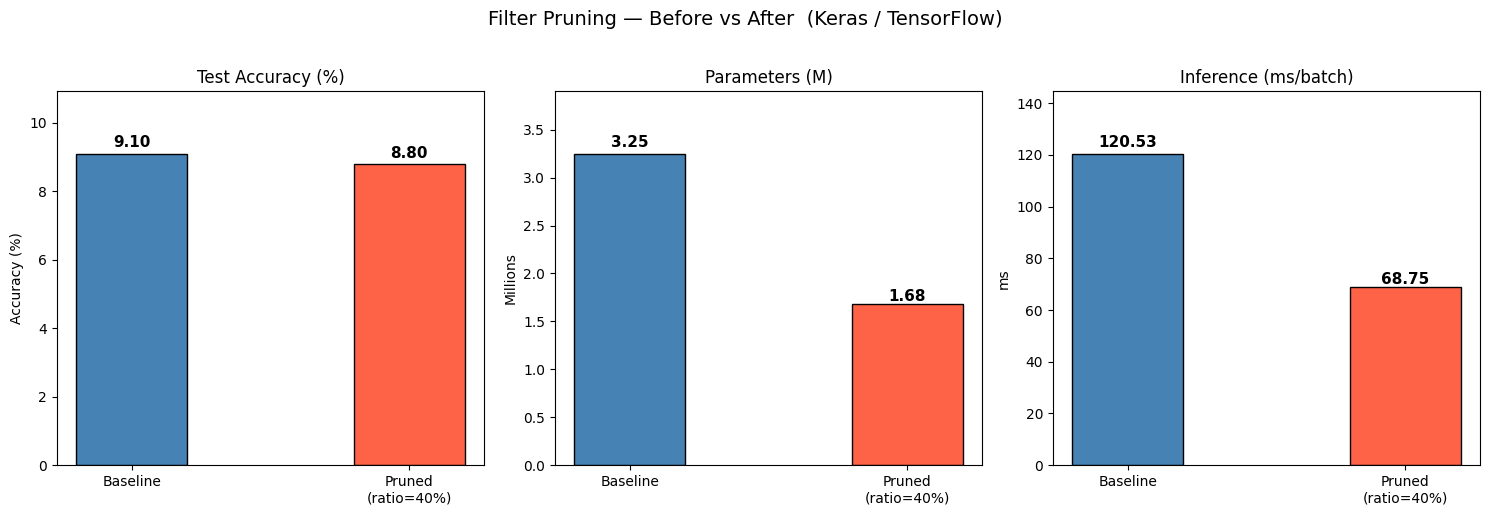

Saved: keras_pruning_comparison.png


In [12]:
labels = ['Baseline', f'Pruned\n(ratio={PRUNE_RATIO*100:.0f}%)']
accs   = [baseline_acc * 100, pruned_acc * 100]
params = [baseline_params,    pruned_params]
times  = [baseline_time,      pruned_time]
colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, values, title, ylabel in zip(
    axes,
    [accs, [p/1e6 for p in params], times],
    ['Test Accuracy (%)', 'Parameters (M)', 'Inference (ms/batch)'],
    ['Accuracy (%)', 'Millions', 'ms']
):
    bars = ax.bar(labels, values, color=colors, width=0.4, edgecolor='black')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.2)

plt.suptitle(f'Filter Pruning — Before vs After  '
             f'(Keras / TensorFlow)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('keras_pruning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: keras_pruning_comparison.png')

## 11. Filter Norm Distributions — Before vs After

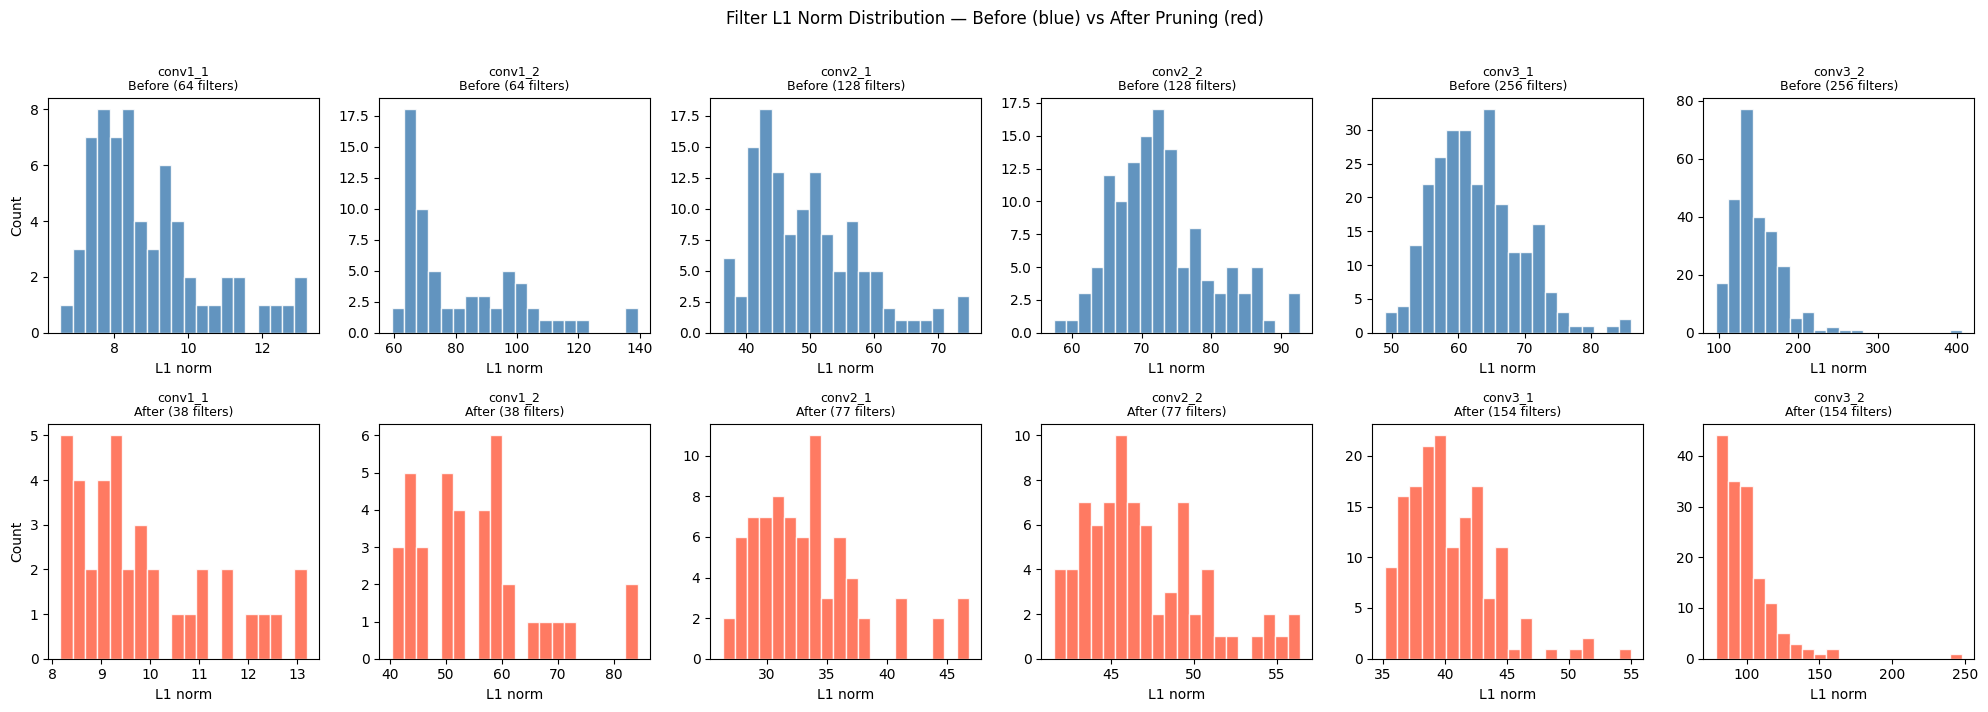

In [13]:
base_convs   = get_conv_layers(baseline_model)
pruned_convs = get_conv_layers(pruned_model)

fig, axes = plt.subplots(2, 6, figsize=(20, 7), sharey=False)

for idx in range(min(6, len(base_convs))):
    norms_b = filter_l1_norms(base_convs[idx])
    norms_p = filter_l1_norms(pruned_convs[idx])

    axes[0, idx].hist(norms_b, bins=20, color='steelblue', alpha=0.85, edgecolor='white')
    axes[0, idx].set_title(f'{base_convs[idx].name}\nBefore ({len(norms_b)} filters)', fontsize=9)
    axes[0, idx].set_xlabel('L1 norm')
    if idx == 0: axes[0, idx].set_ylabel('Count')

    axes[1, idx].hist(norms_p, bins=20, color='tomato', alpha=0.85, edgecolor='white')
    axes[1, idx].set_title(f'{pruned_convs[idx].name}\nAfter ({len(norms_p)} filters)', fontsize=9)
    axes[1, idx].set_xlabel('L1 norm')
    if idx == 0: axes[1, idx].set_ylabel('Count')

plt.suptitle('Filter L1 Norm Distribution — Before (blue) vs After Pruning (red)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 12. Prune-Ratio Sweep (Trade-off Curve)

Zero-shot evaluation at several pruning ratios — no fine-tuning —  
to visualize the accuracy vs. compression trade-off quickly.

ratio=0.0 | acc=9.10% | params=3,250,890
conv1_1     : 64 → 57 filters kept
conv1_2     : 64 → 57 filters kept
conv2_1     : 128 → 115 filters kept
conv2_2     : 128 → 115 filters kept
conv3_1     : 256 → 230 filters kept
conv3_2     : 256 → 230 filters kept


ratio=0.1 | acc=10.00% | params=2,815,968
conv1_1     : 64 → 51 filters kept
conv1_2     : 64 → 51 filters kept
conv2_1     : 128 → 102 filters kept
conv2_2     : 128 → 102 filters kept
conv3_1     : 256 → 205 filters kept
conv3_2     : 256 → 205 filters kept


ratio=0.2 | acc=11.60% | params=2,419,521
conv1_1     : 64 → 45 filters kept
conv1_2     : 64 → 45 filters kept
conv2_1     : 128 → 89 filters kept
conv2_2     : 128 → 89 filters kept
conv3_1     : 256 → 179 filters kept
conv3_2     : 256 → 179 filters kept


ratio=0.3 | acc=9.00% | params=2,033,036
conv1_1     : 64 → 38 filters kept
conv1_2     : 64 → 38 filters kept
conv2_1     : 128 → 77 filters kept
conv2_2     : 128 → 77 filters kept
conv3_1     : 256 → 154 filters kept
conv3_2     : 256 → 154 filters kept


ratio=0.4 | acc=9.00% | params=1,683,245
conv1_1     : 64 → 32 filters kept
conv1_2     : 64 → 32 filters kept
conv2_1     : 128 → 64 filters kept
conv2_2     : 128 → 64 filters kept
conv3_1     : 256 → 128 filters kept
conv3_2     : 256 → 128 filters kept


ratio=0.5 | acc=9.00% | params=1,342,570
conv1_1     : 64 → 26 filters kept
conv1_2     : 64 → 26 filters kept
conv2_1     : 128 → 51 filters kept
conv2_2     : 128 → 51 filters kept
conv3_1     : 256 → 103 filters kept
conv3_2     : 256 → 103 filters kept


ratio=0.6 | acc=9.00% | params=1,035,745
conv1_1     : 64 → 19 filters kept
conv1_2     : 64 → 19 filters kept
conv2_1     : 128 → 39 filters kept
conv2_2     : 128 → 39 filters kept
conv3_1     : 256 → 77 filters kept
conv3_2     : 256 → 77 filters kept


ratio=0.7 | acc=9.00% | params=742,014


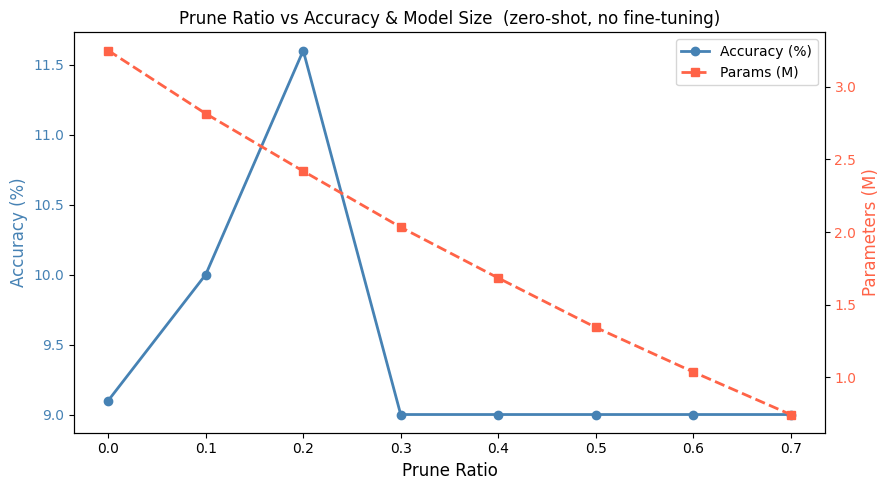

In [14]:
sweep_ratios, sweep_accs, sweep_params = [], [], []

for ratio in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    if ratio == 0.0:
        sweep_accs.append(baseline_acc * 100)
        sweep_params.append(baseline_params)
        sweep_ratios.append(ratio)
        print(f'ratio=0.0 | acc={baseline_acc*100:.2f}% | params={baseline_params:,}')
        continue

    m = build_pruned_model(baseline_model, ratio)
    _, acc = m.evaluate(test_ds, verbose=0)
    sweep_accs.append(acc * 100)
    sweep_params.append(m.count_params())
    sweep_ratios.append(ratio)
    print(f'ratio={ratio:.1f} | acc={acc*100:.2f}% | params={m.count_params():,}')


fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(sweep_ratios, sweep_accs, 'o-', color='steelblue', linewidth=2, label='Accuracy (%)')
ax1.set_xlabel('Prune Ratio', fontsize=12)
ax1.set_ylabel('Accuracy (%)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(sweep_ratios, [p/1e6 for p in sweep_params], 's--',
         color='tomato', linewidth=2, label='Params (M)')
ax2.set_ylabel('Parameters (M)', color='tomato', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper right')
plt.title('Prune Ratio vs Accuracy & Model Size  (zero-shot, no fine-tuning)', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Save & Reload Pruned Model

In [15]:
# Save in Keras native format
pruned_model.save('pruned_cnn.keras')
print('Saved: pruned_cnn.keras')

# Reload and verify accuracy
reloaded = keras.models.load_model('pruned_cnn.keras')
_, reload_acc = reloaded.evaluate(test_ds, verbose=0)
print(f'Reloaded model accuracy: {reload_acc*100:.2f}%')

Saved: pruned_cnn.keras


Reloaded model accuracy: 8.80%


## 14. Key Takeaways

| Observation | Explanation |
|---|---|
| Accuracy drops right after pruning | Removing filters disrupts learned feature representations |
| Fine-tuning recovers most accuracy | Remaining filters adapt to compensate |
| Parameters decrease proportionally | Directly fewer weights in pruned Conv2D layers |
| Speed-up is real but modest | Irregular sparsity and memory-bandwidth effects limit gains |
| L1-norm is an effective proxy | Cheap to compute, strong correlation with filter importance |

### Possible Extensions
- **Structured channel pruning** with Taylor-expansion-based importance scores
- Combine pruning with **`keras-surgeon`** or **TensorFlow Model Optimization Toolkit**
- Export to **TFLite** for mobile deployment after pruning
- Combine with **knowledge distillation** for improved accuracy recovery